In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

In [ ]:
penumpang_januri = pd.read_csv('/content/data-penumpang-bus-transjakarta-januari-2021.csv')
penumpang_februari = pd.read_csv('/content/data-penumpang-bus-transjakarta-februari-2021.csv')
penumpang_maret = pd.read_csv('/content/data-penumpang-bus-transjakarta-maret-2021.csv')
penumpang_april = pd.read_csv('/content/data-penumpang-bus-transjakarta-april-2021.csv')
penumpang_mei = pd.read_csv('/content/data-penumpang-bus-transjakarta-mei-2021.csv')
penumpang_juni = pd.read_csv('/content/data-penumpang-bus-transjakarta-juni-2021.csv')
penumpang_juli = pd.read_csv('/content/data-penumpang-bus-transjakarta-juli-2021.csv')
penumpang_agustus = pd.read_csv('/content/data-penumpang-bus-transjakarta-agustus-2021.csv')
penumpang_september = pd.read_csv('/content/data-penumpang-bus-transjakarta-september-2021.csv')
penumpang_oktober = pd.read_csv('/content/data-penumpang-bus-transjakarta-oktober-2021.csv')
penumpang_november = pd.read_csv('/content/data-penumpang-bus-transjakarta-november-2021.csv')
penumpang_desember = pd.read_csv('/content/data-penumpang-bus-transjakarta-desember-2021.csv')

In [ ]:
df = pd.concat([
    penumpang_januri,
    penumpang_februari,
    penumpang_maret,
    penumpang_april,
    penumpang_mei,
    penumpang_juni,
    penumpang_juli,
    penumpang_agustus,
    penumpang_september,
    penumpang_oktober,
    penumpang_november,
    penumpang_desember
], ignore_index=True)

df


,tahun,bulan,jenis,kode_trayek,trayek,jumlah_penumpang
0,2021,1,Mikrotrans,JAK.88,Terminal Tanjung Priok - Ancol Barat,1473
1,2021,1,Mikrotrans,JAK.85,Bintara - Cipinang Indah,20280
2,2021,1,Mikrotrans,JAK.84,Terminal Kampung Melayu - Kapin Raya,28779
3,2021,1,Mikrotrans,JAK.80,Rawa Buaya - Rawa Kompeni,54998
4,2021,1,Mikrotrans,JA.77,Tanjung Priok - Jembatan Item,60284
...,...,...,...,...,...,...
1468,2021,12,Angkutan Umum Integrasi,1A,PIK - Balai Kota,0
1469,2021,12,Angkutan Umum Integrasi,12B,Pluit - Senen,0
1470,2021,12,Angkutan Umum Integrasi,11Q,Kampung Melayu - Pulo Gebang via BKT,0
1471,2021,12,Angkutan Umum Integrasi,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0


In [ ]:
missing_summary = df.isna().sum()
missing_percentage = (df.isna().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing_summary,
    "Missing %": missing_percentage,
    "Dtype": df.dtypes
})

print("Missing value :")
print(missing_df)

Missing value :
                  Missing Count  Missing %   Dtype
tahun                         0       0.00   int64
bulan                         0       0.00   int64
jenis                         0       0.00  object
kode_trayek                   0       0.00  object
trayek                        2       0.14  object
jumlah_penumpang              0       0.00   int64


In [ ]:
# buat mapping kode_trayek -> trayek (ambil nilai trayek yang tidak missing)
mapping_trayek = (
    df
    .dropna(subset=['trayek'])
    .drop_duplicates(subset=['kode_trayek'])
    .set_index('kode_trayek')['trayek']
)

# isi missing value trayek berdasarkan kode_trayek
df['trayek'] = df['trayek'].fillna(
    df['kode_trayek'].map(mapping_trayek)
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tahun             1473 non-null   int64 
 1   bulan             1473 non-null   int64 
 2   jenis             1473 non-null   object
 3   kode_trayek       1473 non-null   object
 4   trayek            1473 non-null   object
 5   jumlah_penumpang  1473 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 69.2+ KB


In [ ]:
# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Fungsi untuk format angka dengan titik (ribuan)
def format_thousands(x, pos):
    return f'{int(x):,}'.replace(',', '.')

formatter = FuncFormatter(format_thousands)

# 1. TOP 10 BUSIEST ROUTES (PARETO ANALYSIS)


ANALISIS 1: 10 RUTE TERPADAT


/tmp/ipython-input-4134747340.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_routes['label'] = top_10_routes['trayek'] + ' (' + top_10_routes['jenis'] + ')'


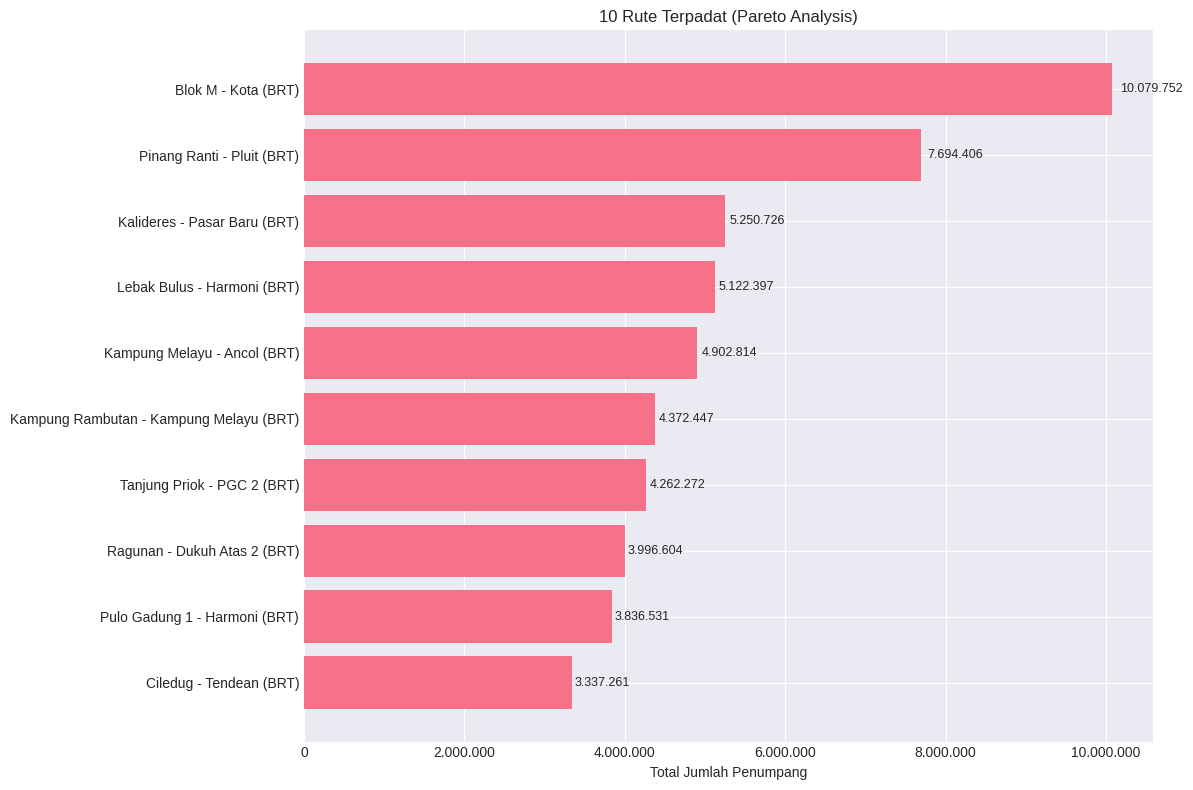


Top 10 Rute Terpadat:
kode_trayek                            trayek jenis  jumlah_penumpang
          1                     Blok M - Kota   BRT          10079752
          9              Pinang Ranti - Pluit   BRT           7694406
          3            Kalideres - Pasar Baru   BRT           5250726
          8             Lebak Bulus - Harmoni   BRT           5122397
          5            Kampung Melayu - Ancol   BRT           4902814
          7 Kampung Rambutan - Kampung Melayu   BRT           4372447
         10             Tanjung Priok - PGC 2   BRT           4262272
          6            Ragunan - Dukuh Atas 2   BRT           3996604
          2           Pulo Gadung 1 - Harmoni   BRT           3836531
         13                 Ciledug - Tendean   BRT           3337261

Total penumpang top 10: 52.855.210
Persentase dari total: 43.9%


In [ ]:
print("="*50)
print("ANALISIS 1: 10 RUTE TERPADAT")
print("="*50)

# Hitung total penumpang per rute
route_totals = df.groupby(['kode_trayek', 'trayek', 'jenis'])['jumlah_penumpang'].sum().reset_index()
route_totals = route_totals.sort_values('jumlah_penumpang', ascending=False)

# Ambil top 10
top_10_routes = route_totals.head(10)

# Buat label untuk chart
top_10_routes['label'] = top_10_routes['trayek'] + ' (' + top_10_routes['jenis'] + ')'

# Visualisasi
fig1, ax1 = plt.subplots(figsize=(12, 8))
bars = ax1.barh(top_10_routes['label'], top_10_routes['jumlah_penumpang'])
ax1.invert_yaxis()  # Yang terbesar di atas
ax1.set_xlabel('Total Jumlah Penumpang')
ax1.set_title('10 Rute Terpadat (Pareto Analysis)')

# Format angka di sumbu x
ax1.xaxis.set_major_formatter(formatter)

# Tambah nilai di ujung bar
for i, (bar, value) in enumerate(zip(bars, top_10_routes['jumlah_penumpang'])):
    ax1.text(value + value*0.01, bar.get_y() + bar.get_height()/2,
             f'{value:,.0f}'.replace(',', '.'),
             va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

# Tampilkan data tabel
print("\nTop 10 Rute Terpadat:")
print(top_10_routes[['kode_trayek', 'trayek', 'jenis', 'jumlah_penumpang']].to_string(index=False))
print(f"\nTotal penumpang top 10: {top_10_routes['jumlah_penumpang'].sum():,.0f}".replace(',', '.'))
print(f"Persentase dari total: {(top_10_routes['jumlah_penumpang'].sum() / route_totals['jumlah_penumpang'].sum() * 100):.1f}%")

# 2. MONTHLY TREND ANALYSIS (SEASONALITY)


ANALISIS 2: TREN BULANAN (SEASONALITY)


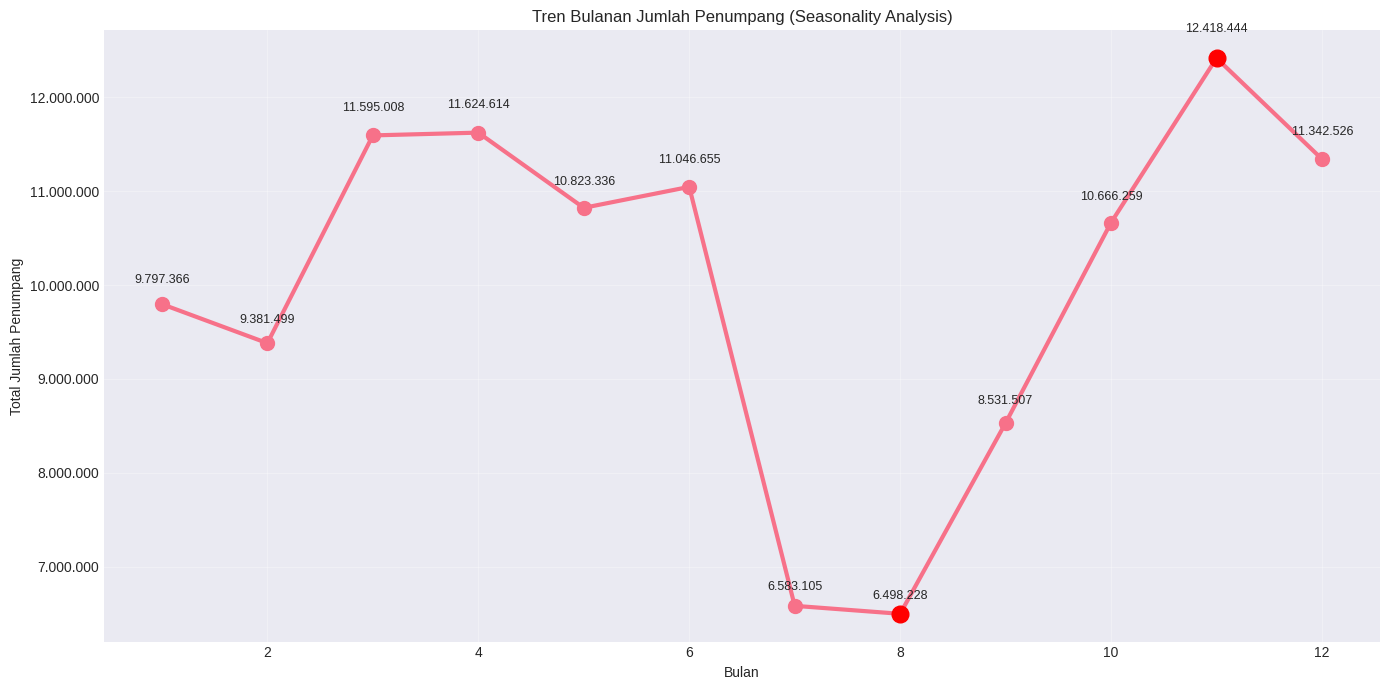


Total Penumpang per Bulan:
 bulan  jumlah_penumpang
     1           9797366
     2           9381499
     3          11595008
     4          11624614
     5          10823336
     6          11046655
     7           6583105
     8           6498228
     9           8531507
    10          10666259
    11          12418444
    12          11342526


In [ ]:
print("\n" + "="*50)
print("ANALISIS 2: TREN BULANAN (SEASONALITY)")
print("="*50)

# Group by bulan (aggregate semua tahun)
monthly_totals = (
    df.groupby('bulan', as_index=False)['jumlah_penumpang']
      .sum()
      .sort_values('bulan')
)

# Visualisasi
fig2, ax3 = plt.subplots(figsize=(14, 7))

# Plot line chart
line = ax3.plot(monthly_totals['bulan'], monthly_totals['jumlah_penumpang'],
                marker='o', linewidth=3, markersize=10)

ax3.set_xlabel('Bulan')
ax3.set_ylabel('Total Jumlah Penumpang')
ax3.set_title('Tren Bulanan Jumlah Penumpang (Seasonality Analysis)')
ax3.grid(True, alpha=0.3)

# Format angka di sumbu y
ax3.yaxis.set_major_formatter(formatter)

# Tambah nilai di setiap titik
for x, y in zip(monthly_totals['bulan'], monthly_totals['jumlah_penumpang']):
    ax3.text(x, y + y*0.02, f'{y:,.0f}'.replace(',', '.'),
             ha='center', va='bottom', fontsize=9)

# Highlight bulan dengan penumpang tertinggi dan terendah
max_month = monthly_totals.loc[monthly_totals['jumlah_penumpang'].idxmax()]
min_month = monthly_totals.loc[monthly_totals['jumlah_penumpang'].idxmin()]

ax3.plot(max_month['bulan'], max_month['jumlah_penumpang'], 'ro', markersize=12)
ax3.plot(min_month['bulan'], min_month['jumlah_penumpang'], 'ro', markersize=12)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Tampilkan data tabel
print("\nTotal Penumpang per Bulan:")
print(monthly_totals[['bulan', 'jumlah_penumpang']].to_string(index=False))

# 3. ROUTE CLUSTERING (INNOVATION)



ANALISIS 3: CLUSTERING RUTE BERDASARKAN PRIORITAS


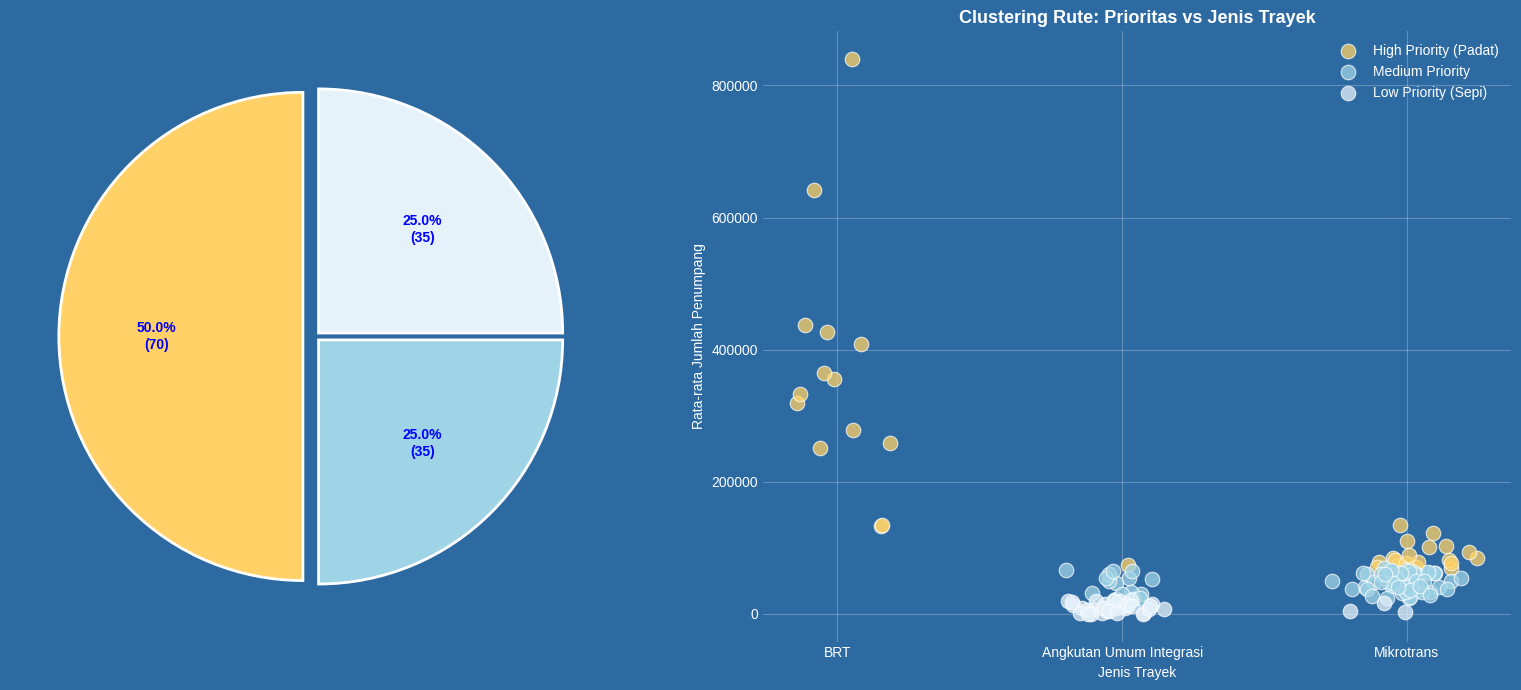


STATISTIK CLUSTERING RUTE:
----------------------------------------
Threshold untuk kategorisasi:
  - High Priority: ≥ 69.729
  - Medium Priority: 21.225 - 69.729
  - Low Priority: < 21.225

Distribusi Rute per Prioritas:
  Medium Priority: 70 rute (50.0%)
  High Priority (Padat): 35 rute (25.0%)
  Low Priority (Sepi): 35 rute (25.0%)

Detail per Jenis Trayek:
priority                 High Priority (Padat)  Low Priority (Sepi)  \
jenis                                                                 
Angkutan Umum Integrasi                      1                   32   
BRT                                         14                    0   
Mikrotrans                                  20                    3   

priority                 Medium Priority  
jenis                                     
Angkutan Umum Integrasi               17  
BRT                                    0  
Mikrotrans                            53  

5 RUTE DENGAN PRIORITAS TERTINGGI:
kode_trayek                 t

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*50)
print("ANALISIS 3: CLUSTERING RUTE BERDASARKAN PRIORITAS")
print("="*50)

# ================================
# HITUNG RATA-RATA PENUMPANG
# ================================
route_avg = (
    df.groupby(['kode_trayek', 'trayek', 'jenis'])['jumlah_penumpang']
      .agg(['mean', 'count'])
      .reset_index()
)

route_avg.columns = [
    'kode_trayek', 'trayek', 'jenis',
    'avg_penumpang', 'jumlah_data'
]

# ================================
# THRESHOLD CLUSTERING
# ================================
high_threshold = route_avg['avg_penumpang'].quantile(0.75)
medium_threshold = route_avg['avg_penumpang'].quantile(0.25)

def categorize_route(avg_passengers):
    if avg_passengers >= high_threshold:
        return 'High Priority (Padat)'
    elif avg_passengers >= medium_threshold:
        return 'Medium Priority'
    else:
        return 'Low Priority (Sepi)'

route_avg['priority'] = route_avg['avg_penumpang'].apply(categorize_route)

priority_dist = route_avg['priority'].value_counts()
priority_percentage = route_avg['priority'].value_counts(normalize=True) * 100

# ================================
# SET WARNA (POSTER FRIENDLY)
# ================================
bg_color = '#2d6aa2'

pie_colors = [
    '#FFD166',  # High Priority
    '#9FD3E6',  # Medium Priority
    '#E6F2FA'   # Low Priority
]

scatter_colors = {
    'High Priority (Padat)': '#FFD166',
    'Medium Priority': '#9FD3E6',
    'Low Priority (Sepi)': '#E6F2FA'
}

# ================================
# VISUALISASI
# ================================
fig3, (ax4, ax5) = plt.subplots(1, 2, figsize=(16, 7))

# Background
fig3.patch.set_facecolor(bg_color)
ax4.set_facecolor(bg_color)
ax5.set_facecolor(bg_color)

# ================================
# PIE CHART
# ================================
# ================================
# PIE CHART - DENGAN LEGEND YANG BENAR
# ================================
# Hitung nilai untuk custom autopct
total_routes = priority_dist.sum()

# Buat fungsi untuk format autopct
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val:d})'
    return my_autopct

# Create pie chart dengan autopct yang benar
wedges, texts, autotexts = ax4.pie(
    priority_dist.values,
    labels=None,  # Tidak pakai label default
    autopct=make_autopct(priority_dist.values),
    colors=pie_colors,
    startangle=90,
    explode=(0.05, 0.02, 0.02),
    textprops={'color': 'blue', 'fontsize': 10, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# ================================
# SCATTER PLOT
# ================================
jenis_mapping = {j: i for i, j in enumerate(route_avg['jenis'].unique())}
route_avg['jenis_numeric'] = route_avg['jenis'].map(jenis_mapping)

np.random.seed(42)
route_avg['jenis_numeric'] += np.random.normal(0, 0.1, len(route_avg))

for priority, color in scatter_colors.items():
    subset = route_avg[route_avg['priority'] == priority]
    ax5.scatter(
        subset['jenis_numeric'],
        subset['avg_penumpang'],
        s=110,
        alpha=0.75,
        color=color,
        label=priority,
        edgecolors='white',
        linewidths=0.8
    )

ax5.set_xlabel('Jenis Trayek', color='white')
ax5.set_ylabel('Rata-rata Jumlah Penumpang', color='white')
ax5.set_title(
    'Clustering Rute: Prioritas vs Jenis Trayek',
    color='white',
    fontsize=13,
    fontweight='bold'
)

ax5.set_xticks(range(len(jenis_mapping)))
ax5.set_xticklabels(jenis_mapping.keys(), color='white')

ax5.tick_params(axis='y', colors='white')
ax5.grid(True, alpha=0.25, color='white')

legend = ax5.legend(frameon=False)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

# ================================
# OUTPUT STATISTIK
# ================================
print("\nSTATISTIK CLUSTERING RUTE:")
print("-" * 40)
print("Threshold untuk kategorisasi:")
print(f"  - High Priority: ≥ {high_threshold:,.0f}".replace(',', '.'))
print(f"  - Medium Priority: {medium_threshold:,.0f} - {high_threshold:,.0f}".replace(',', '.'))
print(f"  - Low Priority: < {medium_threshold:,.0f}".replace(',', '.'))

print("\nDistribusi Rute per Prioritas:")
for priority in priority_dist.index:
    print(f"  {priority}: {priority_dist[priority]} rute ({priority_percentage[priority]:.1f}%)")

print("\nDetail per Jenis Trayek:")
print(pd.crosstab(route_avg['jenis'], route_avg['priority']))

print("\n5 RUTE DENGAN PRIORITAS TERTINGGI:")
print(
    route_avg.sort_values('avg_penumpang', ascending=False)
             [['kode_trayek', 'trayek', 'jenis', 'avg_penumpang', 'priority']]
             .head()
             .to_string(index=False)
)

print("\n5 RUTE DENGAN PRIORITAS TERENDAH:")
print(
    route_avg.sort_values('avg_penumpang')
             [['kode_trayek', 'trayek', 'jenis', 'avg_penumpang', 'priority']]
             .head()
             .to_string(index=False)
)

In [ ]:
# 4. REKOMENDASI STRATEGIS
print("\n" + "="*50)
print("REKOMENDASI STRATEGIS BERDASARKAN ANALISIS")
print("="*50)

high_priority_routes = route_avg[route_avg['priority'] == 'High Priority (Padat)']
low_priority_routes = route_avg[route_avg['priority'] == 'Low Priority (Sepi)']

print("1. REKOMENDASI UNTUK RUTE HIGH PRIORITY (PADAT):")
print(f"   - Jumlah rute: {len(high_priority_routes)}")
print(f"   - Rata-rata penumpang: {high_priority_routes['avg_penumpang'].mean():,.0f}/bulan".replace(',', '.'))
print("   - Tindakan: Tambah frekuensi, gunakan armada besar, monitor real-time")

print("\n2. REKOMENDASI UNTUK RUTE LOW PRIORITY (SEPI):")
print(f"   - Jumlah rute: {len(low_priority_routes)}")
print(f"   - Rata-rata penumpang: {low_priority_routes['avg_penumpang'].mean():,.0f}/bulan".replace(',', '.'))
print("   - Tindakan: Evaluasi keberlanjutan, pertimbangkan konsolidasi rute")

print("\n3. REKOMENDASI OPERASIONAL:")
print(f"   - Fokus pada bulan {max_month['bulan']} untuk persiapan ekstra")
print(f"   - Optimalkan rute top 10 yang menyumbang {(top_10_routes['jumlah_penumpang'].sum() / route_totals['jumlah_penumpang'].sum() * 100):.1f}% total penumpang")


REKOMENDASI STRATEGIS BERDASARKAN ANALISIS
1. REKOMENDASI UNTUK RUTE HIGH PRIORITY (PADAT):
   - Jumlah rute: 35
   - Rata-rata penumpang: 200.397/bulan
   - Tindakan: Tambah frekuensi, gunakan armada besar, monitor real-time

2. REKOMENDASI UNTUK RUTE LOW PRIORITY (SEPI):
   - Jumlah rute: 35
   - Rata-rata penumpang: 9.507/bulan
   - Tindakan: Evaluasi keberlanjutan, pertimbangkan konsolidasi rute

3. REKOMENDASI OPERASIONAL:
   - Fokus pada bulan 11 untuk persiapan ekstra
   - Optimalkan rute top 10 yang menyumbang 43.9% total penumpang
